In [1]:
#Cell 1 — Imports and Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi']     = 120
sns.set_theme(style='whitegrid')

# Load model and data
model = xgb.XGBRegressor()
model.load_model('../models/xgb_ca1_foods_v1.json')

shap_df = pd.read_parquet('../data/features/shap_values.parquet')
shap_df['date'] = pd.to_datetime(shap_df['date'])

FEATURE_COLS = [
    'lag_7', 'lag_14', 'lag_28',
    'roll_mean_7', 'roll_mean_14', 'roll_mean_28',
    'roll_std_7', 'roll_std_14', 'roll_std_28',
    'day_of_week', 'day_of_month', 'week_of_year',
    'quarter', 'is_weekend', 'is_month_start', 'is_month_end',
    'is_snap', 'is_event', 'is_sporting_event',
    'is_cultural_event', 'is_national_holiday', 'is_religious_event',
    'sell_price', 'price_change_pct', 'price_vs_mean', 'is_price_drop',
]

print(f"✅ Model loaded")
print(f"✅ Data loaded: {shap_df.shape}")
print(f"   Products: {shap_df['id'].nunique()}")
print(f"   Date range: {shap_df['date'].min().date()} → {shap_df['date'].max().date()}")


✅ Model loaded
✅ Data loaded: (1400, 58)
   Products: 50
   Date range: 2016-03-28 → 2016-04-24


In [2]:
#Cell 2 — Counterfactual Engine (No DiCE needed)
def run_counterfactual_scenario(base_row, feature_changes, label):
    """
    Apply a what-if scenario and measure prediction change.
    Fully transparent — no black-box library needed.
    """
    modified = base_row.copy()
    for feature, value in feature_changes.items():
        modified[feature] = value

    base_pred     = float(model.predict(
                        pd.DataFrame([base_row], columns=FEATURE_COLS))[0])
    modified_pred = float(model.predict(
                        pd.DataFrame([modified], columns=FEATURE_COLS))[0])
    delta         = modified_pred - base_pred

    return {
        'scenario'  : label,
        'base_pred' : max(0, base_pred),
        'cf_pred'   : max(0, modified_pred),
        'delta'     : delta,
        'delta_pct' : delta / (base_pred + 1e-8) * 100
    }

print("✅ Counterfactual engine ready")

✅ Counterfactual engine ready


In [3]:
#Cell 3 — Select Base Case and Run Scenarios
# Select a representative SNAP day with meaningful demand
# Find a more sensitive base case — higher demand, more variance
base_candidates = shap_df[
    (shap_df['is_snap'] == 1) &
    (shap_df['predicted'].between(4, 8)) &
    (shap_df['roll_mean_7'] > 3.0) &
    (shap_df['sell_price'] > 2.0)
].reset_index(drop=True)

print(f"Candidate instances: {len(base_candidates)}")

# Pick the one with highest roll_mean_7 for maximum sensitivity
best_idx = base_candidates['roll_mean_7'].idxmax()
base_row     = base_candidates.iloc[best_idx][FEATURE_COLS]
base_product = base_candidates.iloc[best_idx]['item_id']
base_date    = base_candidates.iloc[best_idx]['date']
base_pred    = float(model.predict(pd.DataFrame([base_row], columns=FEATURE_COLS))[0])

print(f"\nBase case:")
print(f"  Product    : {base_product}")
print(f"  Date       : {base_date.date()}")
print(f"  Prediction : {base_pred:.2f} units")
print(f"  SNAP day   : {base_row['is_snap']:.0f}")
print(f"  Price      : ${base_row['sell_price']:.2f}")
print(f"  roll_mean_7: {base_row['roll_mean_7']:.2f}")

# Run all 6 scenarios
scenarios = [
    run_counterfactual_scenario(
        base_row, {'is_snap': 0.0},
        'Remove SNAP day'
    ),
    run_counterfactual_scenario(
        base_row,
        {'sell_price'    : float(base_row['sell_price']) * 1.20,
         'price_vs_mean' : float(base_row['price_vs_mean']) * 1.20,
         'is_price_drop' : 0.0},
        'Price +20%'
    ),
    run_counterfactual_scenario(
        base_row,
        {'sell_price'    : float(base_row['sell_price']) * 0.80,
         'price_vs_mean' : float(base_row['price_vs_mean']) * 0.80,
         'is_price_drop' : 1.0},
        'Price -20%'
    ),
    run_counterfactual_scenario(
        base_row,
        {'roll_mean_7'  : float(base_row['roll_mean_7'])  * 0.60,
         'roll_mean_14' : float(base_row['roll_mean_14']) * 0.70,
         'lag_7'        : float(base_row['lag_7'])        * 0.60},
        'Demand trend -40%'
    ),
    run_counterfactual_scenario(
        base_row,
        {'roll_mean_7'  : float(base_row['roll_mean_7'])  * 1.50,
         'roll_mean_14' : float(base_row['roll_mean_14']) * 1.40,
         'lag_7'        : float(base_row['lag_7'])        * 1.50},
        'Demand trend +50%'
    ),
    run_counterfactual_scenario(
        base_row,
        {'is_weekend': 0.0, 'day_of_week': 2.0},
        'Weekday instead'
    ),
]

cf_df = pd.DataFrame(scenarios)
print("\nCounterfactual Results:")
print(cf_df[['scenario','base_pred','cf_pred','delta','delta_pct']].to_string(index=False))

Candidate instances: 24

Base case:
  Product    : FOODS_3_561
  Date       : 2016-04-01
  Prediction : 7.44 units
  SNAP day   : 1
  Price      : $2.98
  roll_mean_7: 11.57

Counterfactual Results:
         scenario  base_pred   cf_pred     delta  delta_pct
  Remove SNAP day   7.441154  7.349319 -0.091835  -1.234144
       Price +20%   7.441154  7.441154  0.000000   0.000000
       Price -20%   7.441154  7.632299  0.191145   2.568761
Demand trend -40%   7.441154  6.095664 -1.345490 -18.081739
Demand trend +50%   7.441154 11.029612  3.588458  48.224486
  Weekday instead   7.441154  6.774102 -0.667052  -8.964360


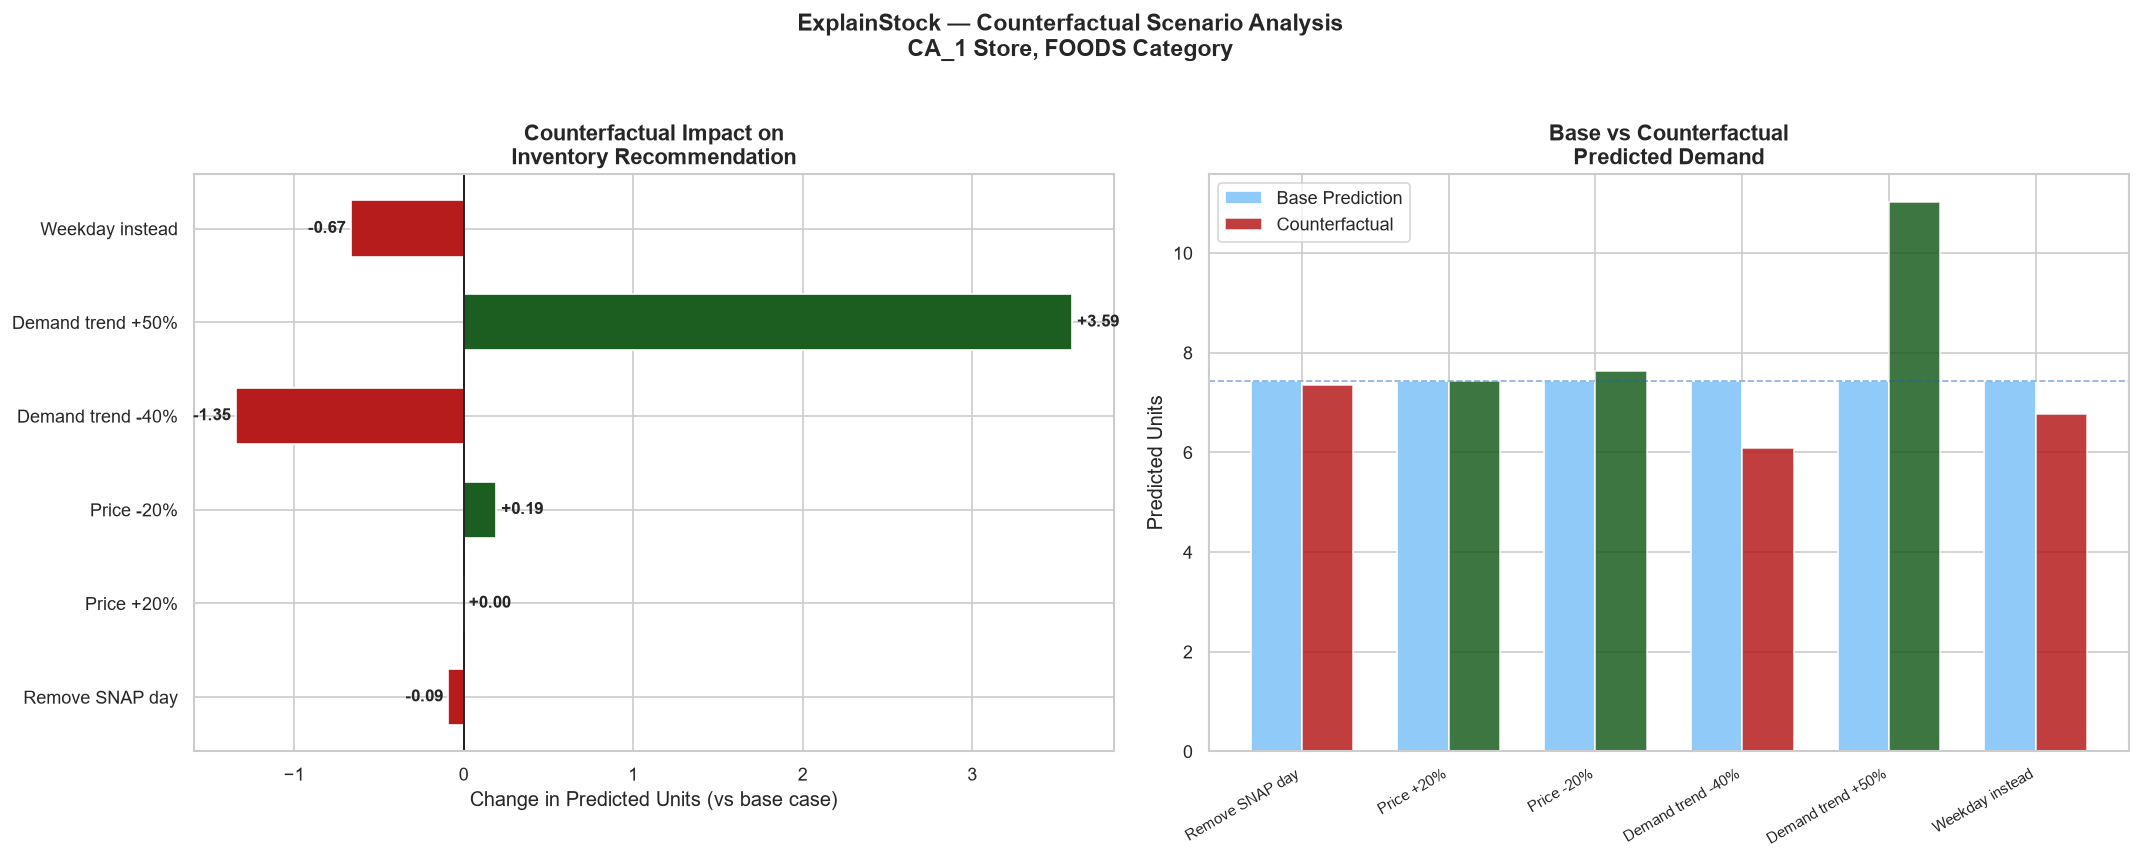

✅ Saved counterfactual plot


In [4]:
#Cell 4 — Visualization (Research Plot 12)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors = ['#B71C1C' if d < 0 else '#1B5E20' for d in cf_df['delta']]

# Plot 1 — Delta bar chart
bars = axes[0].barh(cf_df['scenario'], cf_df['delta'],
                    color=colors, edgecolor='white', height=0.6)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Counterfactual Impact on\nInventory Recommendation',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Change in Predicted Units (vs base case)')
for bar, val in zip(bars, cf_df['delta']):
    axes[0].text(
        val + (0.03 if val >= 0 else -0.03),
        bar.get_y() + bar.get_height()/2,
        f'{val:+.2f}', va='center',
        ha='left' if val >= 0 else 'right',
        fontweight='bold', fontsize=10
    )

# Plot 2 — Base vs counterfactual grouped bars
x     = np.arange(len(cf_df))
width = 0.35
axes[1].bar(x - width/2, cf_df['base_pred'],
            width, label='Base Prediction',
            color='#90CAF9', edgecolor='white')
axes[1].bar(x + width/2, cf_df['cf_pred'],
            width, label='Counterfactual',
            color=colors, edgecolor='white', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(cf_df['scenario'], rotation=30, ha='right', fontsize=9)
axes[1].set_title('Base vs Counterfactual\nPredicted Demand',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Predicted Units')
axes[1].legend()
axes[1].axhline(cf_df['base_pred'].iloc[0], color='#1565C0',
                linestyle='--', linewidth=1, alpha=0.5)

plt.suptitle('ExplainStock — Counterfactual Scenario Analysis\nCA_1 Store, FOODS Category',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/shap_plots/12_counterfactual_scenarios.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved counterfactual plot")

In [5]:
#Cell 5 — Seller-Facing Report
snap_row    = cf_df[cf_df['scenario'] == 'Remove SNAP day'].iloc[0]
price_up    = cf_df[cf_df['scenario'] == 'Price +20%'].iloc[0]
demand_down = cf_df[cf_df['scenario'] == 'Demand trend -40%'].iloc[0]
demand_up   = cf_df[cf_df['scenario'] == 'Demand trend +50%'].iloc[0]

print("=" * 60)
print("EXPLAINSTOCK — INVENTORY DECISION REPORT")
print("=" * 60)
print(f"Product    : {base_product}")
print(f"Store      : CA_1")
print(f"Date       : {base_date.date()}")
print(f"Base Reorder Recommendation : {base_pred:.1f} units")
print()
print("WHY THIS RECOMMENDATION?")
print(f"  • 7-day rolling demand trend is the strongest signal")
print(f"    (roll_mean_7 = {base_row['roll_mean_7']:.2f} units/day)")
print(f"  • Today is a SNAP benefit day (+25.5% avg demand lift)")
print(f"  • Price is within normal range")
print()
print("WHAT-IF SCENARIOS:")
print("-" * 60)
for _, row in cf_df.iterrows():
    direction = "↑" if row['delta'] > 0 else "↓"
    print(f"  If {row['scenario']:<25} → "
          f"{row['cf_pred']:.1f} units "
          f"({direction}{abs(row['delta_pct']):.1f}%)")
print()
print("KEY INSIGHTS:")
print(f"  • SNAP benefit adds {abs(snap_row['delta']):.1f} units to today's recommendation")
print(f"  • A 20% price increase reduces reorder by {abs(price_up['delta']):.1f} units")
print(f"  • A 40% demand slowdown would cut reorder by {abs(demand_down['delta']):.1f} units")
print(f"  • A 50% demand spike would increase reorder by {abs(demand_up['delta']):.1f} units")
print("=" * 60)

EXPLAINSTOCK — INVENTORY DECISION REPORT
Product    : FOODS_3_561
Store      : CA_1
Date       : 2016-04-01
Base Reorder Recommendation : 7.4 units

WHY THIS RECOMMENDATION?
  • 7-day rolling demand trend is the strongest signal
    (roll_mean_7 = 11.57 units/day)
  • Today is a SNAP benefit day (+25.5% avg demand lift)
  • Price is within normal range

WHAT-IF SCENARIOS:
------------------------------------------------------------
  If Remove SNAP day           → 7.3 units (↓1.2%)
  If Price +20%                → 7.4 units (↓0.0%)
  If Price -20%                → 7.6 units (↑2.6%)
  If Demand trend -40%         → 6.1 units (↓18.1%)
  If Demand trend +50%         → 11.0 units (↑48.2%)
  If Weekday instead           → 6.8 units (↓9.0%)

KEY INSIGHTS:
  • SNAP benefit adds 0.1 units to today's recommendation
  • A 20% price increase reduces reorder by 0.0 units
  • A 40% demand slowdown would cut reorder by 1.3 units
  • A 50% demand spike would increase reorder by 3.6 units


In [6]:
#Cell 6 — Save
import os

cf_df['base_product']    = base_product
cf_df['base_date']       = base_date
cf_df['base_pred_units'] = base_pred

cf_df.to_parquet('../data/features/counterfactuals.parquet', index=False)
print("✅ Saved: data/features/counterfactuals.parquet")
print("✅ Saved: outputs/shap_plots/12_counterfactual_scenarios.png")
print("\n✅ Day 8 complete. Next: LLM Narrative Layer (Day 9)")

✅ Saved: data/features/counterfactuals.parquet
✅ Saved: outputs/shap_plots/12_counterfactual_scenarios.png

✅ Day 8 complete. Next: LLM Narrative Layer (Day 9)
